# kNN 알고리즘 (K-Nearest Neighbors) 
#### 특정 공간 내에서 입력과 제일 유사한 k개의 요소를 찾아 더 많이 일치하는 것으로 분류하는 알고리즘
######  hyper 파라미터 : 분류기의 효과를 높이기 위해 파라미터를 조정할 수 있다
######  overfitting : 너무 작은 k 값
######  underfitting : 너무 큰 k 값
######  최적의 k찾기 : 교차검증(cross validation) 시간은 k배로 더 걸리지만(예측속도, 메모리, 노이즈 데이터에 민감) 
######  모델 평가의 억울함(데이터 편향)을 없애고 신뢰도를 100% 높여주는 검증법


In [22]:
# 라이브러리(package) 임포트 : 실습에 필요한 라이브러리를 임포트
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
set_config(display='text')  # display='diagram' Jupyter 환경에서 시각적으로 화려한 HTML 그림으로 표시

import warnings
warnings.filterwarnings('ignore')

# sklearn 모델의 동일한 결과 출력을 위해 선언
np.random.seed(1234)

# 데이터 불러오기(학습데이터, 테스트 데이터)

#### - 데이터 분석 단계에서 생성한 농구 선수 포지션 예측하기의 학습 데이터 및 테스트 데이터를 읽어오기

In [9]:
train = pd.read_csv('basketball_train.csv')
test = pd.read_csv('basketball_test.csv')

print(train.shape[0]) # 훈련용 데이터 셋 갯수(전체 행의 갯수 카운팅)
print(train.shape[1]) # feature의 갯수 (전체 열의 갯수 카운팅)

print(test.shape[0]) # 테스트용 데이터 셋 갯수
print(test.shape[1]) # 테스트용 feature의 갯수

80
5
20
5


In [10]:
# 80% 학습용 데이터, 20% 태스트 데이터
train

,Player,Pos,3P,TRB,BLK
0,Dewayne Dedmon,C,0.0,6.5,0.8
1,Manu Ginobili,SG,1.3,2.3,0.2
2,Salah Mejri,C,0.0,4.2,0.8
3,Nene Hilario,C,0.0,4.2,0.6
4,Jordan Crawford,SG,1.9,1.8,0.1
...,...,...,...,...,...
75,Wayne Ellington,SG,2.4,2.1,0.1
76,Wesley Matthews,SG,2.4,3.5,0.2
77,Patrick Beverley,SG,1.6,5.9,0.4
78,Marcus Smart,SG,1.2,3.9,0.4


## 최적의 k 찾기(교차 검증 - cross validation)
##### validation 데이터 : 훈련 데이터에서 10%만 따로 뽑아내서 확인하는 데이터(특정 데이터에 편중될 가능성이 있음)
##### 적은 수집된 데이터에서 효과적임(기준만 제시하면 훈련 데이터를 등분수 만큼 학습)

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

In [16]:
# 최적의 k 값 찾기
# Player, Pos, 3P,	TRB, BLK

max_k_range = train.shape[0] // 2  # // 몫만 반환하는 연산자 : 최대 반 만큼만 k 값을 늘려가면서 찾기, 80개 데이터 중 40을 넘어가지 않는 39까지
k_list = []

for i in range(3, max_k_range, 2):  # 3, 5, 7, 9, 11....39  증가치 : 2
    k_list.append(i)

# 모델의 학습 데이터
x_train = train[['3P', 'BLK', 'TRB']] # 학습(훈련) 데이터
y_train = train[['Pos']] # 정답 데이터

print(x_train.shape)  # 80행 3열
print(y_train.shape)  # 80행 1열
print(k_list)



(80, 3)
(80, 1)
[3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39]


In [ ]:
# k-fold cross validation(k-폴드 교차 검증법) 
# cross_val_score() 함수
# 머신러닝 모델을 평가할 때 데이터를 여러 조각으로 나누어 돌려가며 검증(교차 검증, Cross-Validation)해주는 Scikit-learn의 핵심 함수
   
# 시간은 K배로 더 걸리지만, 모델 평가의 억울함(데이터 편향)을 없애고 신뢰도를 100% 높여주는 검증법
# 전체 데이터를 k개의 동일한 크기를 가진 부분 집합(Fold, 폴드)으로 나눈 뒤, k번의 평가 과정을 거쳐 모델의 평균 성능을 측정하는 검증 방법
# 데이터를 단 한 번만 '학습용(Train)'과 '검증용(Validation)'으로 쪼개서 평가할 때 발생하는 "운 좋게(또는 운 나쁘게) 나누어진 
# 데이터 때문에 일어나는 평가 편향(Bias)"을 방지하기 위해 사용

cross_validation_score = []

for k in k_list: # 3, 5, 7,...39
    knn = KNeighborsClassifier(n_neighbors=k)  # Knn 알고리즘 적용, n_neighbors=k 해당 k 값을 전달 받음, KNeighborsClassifier는 생성자 함수이므로 리턴타입이 필요(knn = )
    score = cross_val_score(knn, x_train, y_train.values.ravel(),
                    cv=10, scoring='accuracy')   # 교차검증(cv)의 score를 계산(각각의 평가값을 처리)  y_train.values.ravel() 2차원의 데이터를 values를 통해서 배열로 변환한 후 ravel()함수로 1차원으로 변환, 10등분한 정확도를 계산
    
    cross_validation_score.append(score.mean())  # 10개의 개별적 평가값(정확도)의 평균

cross_validation_score  # 출력


[np.float64(0.95),
 np.float64(0.9125),
 np.float64(0.9125),
 np.float64(0.9),
 np.float64(0.8875),
 np.float64(0.8875),
 np.float64(0.8875),
 np.float64(0.9),
 np.float64(0.875),
 np.float64(0.8875),
 np.float64(0.8625),
 np.float64(0.8625),
 np.float64(0.8625),
 np.float64(0.8625),
 np.float64(0.8375),
 np.float64(0.8375),
 np.float64(0.825),
 np.float64(0.825),
 np.float64(0.825)]

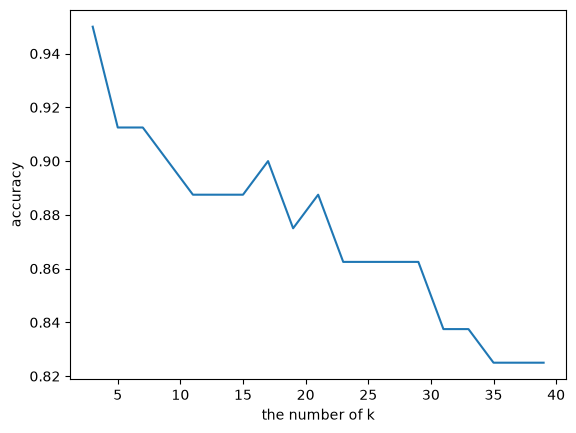

In [24]:
# k-값 시각화

plt.plot(k_list, cross_validation_score)
plt.xlabel('the number of k')
plt.ylabel('accuracy')
plt.show()


In [29]:
cvs = cross_validation_score  # 정확도의 변수
k = k_list[cvs.index(max(cross_validation_score))]  # 0.9(95%)
str(k)

'3'

### - 2개의특징으로 예측하기(3점슛, 블로킹)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=k) # k 값은 3(최적의 정확도)

x_train = train[['3P', 'BLK']] # 학습(훈련)용 데이터
y_train = train[['Pos']]  # 정답 데이터

knn.fit(x_train, y_train.values.ravel())  # fit() 기계(ML)학습 함수, 1차원의 배열의 자료형으로 반환(ravel함수), 학습 시컴

KNeighborsClassifier(n_neighbors=3)

In [32]:
# knn 정확도

x_test = test[['3P', 'BLK']]  # 태스트용 데이터 20% 적용 -> 성능 평가
y_test = test[['Pos']]

pred = knn.predict(x_test)  # predict 예측해봐

pred

array(['SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'SG', 'C', 'SG', 'C',
       'SG', 'SG', 'SG', 'SG', 'SG', 'C', 'C', 'SG', 'C'], dtype=object)

In [ ]:
comparison = pd.DataFrame({'예측값': pred, \
                           '정답': y_test.values.ravel()})
comparison # 90% 정확도

,예측값,정답
0,SG,SG
1,SG,SG
2,SG,SG
3,SG,SG
4,SG,SG
5,SG,C
6,SG,SG
7,SG,C
8,C,C
9,SG,SG


In [35]:
# 정확도
from sklearn.metrics import accuracy_score

print('accuracy : ' + str(accuracy_score(pred, y_test.values.ravel())))

accuracy : 0.9


### - 3개의 특징으로 예측하기(3점슛, 블로킹, 리바운드)

In [36]:
knn = KNeighborsClassifier(n_neighbors=k)

x_train = train[['3P', 'BLK', 'TRB']]
y_train = train[['Pos']]

knn.fit(x_train, y_train.values.ravel())

KNeighborsClassifier(n_neighbors=3)

In [37]:
# knn 정확도

x_test = test[['3P', 'BLK', 'TRB']]
y_test = test[['Pos']]

pred = knn.predict(x_test)

In [38]:
comparison = pd.DataFrame({'예측값':pred, \
                           '정답':y_test.values.ravel()})
comparison

,예측값,정답
0,SG,SG
1,SG,SG
2,SG,SG
3,SG,SG
4,SG,SG
5,SG,C
6,SG,SG
7,SG,C
8,C,C
9,SG,SG


In [39]:
# 정확도

print('accuracy : ' + str(accuracy_score(pred, y_test.values.ravel())))

accuracy : 0.9
